In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [ ]:
# FOLDS
folds_mlp = pd.read_csv("folds_mlp.csv")
folds_cnn = pd.read_csv("folds_cnn.csv")
folds_lstm = pd.read_csv("folds_lstm.csv")

# TEST
results_mlp = pd.read_csv("results_mlp.csv", index_col=0)
results_cnn = pd.read_csv("results_cnn.csv", index_col=0)
results_lstm = pd.read_csv("results_lstm.csv", index_col=0)

In [ ]:
folds_mlp["model"] = "MLP"
folds_cnn["model"] = "CNN"
folds_lstm["model"] = "LSTM"

all_folds = pd.concat([folds_mlp, folds_cnn, folds_lstm])

# Identificador único
all_folds["model_dataset"] = all_folds["model"] + "_" + all_folds["dataset"]

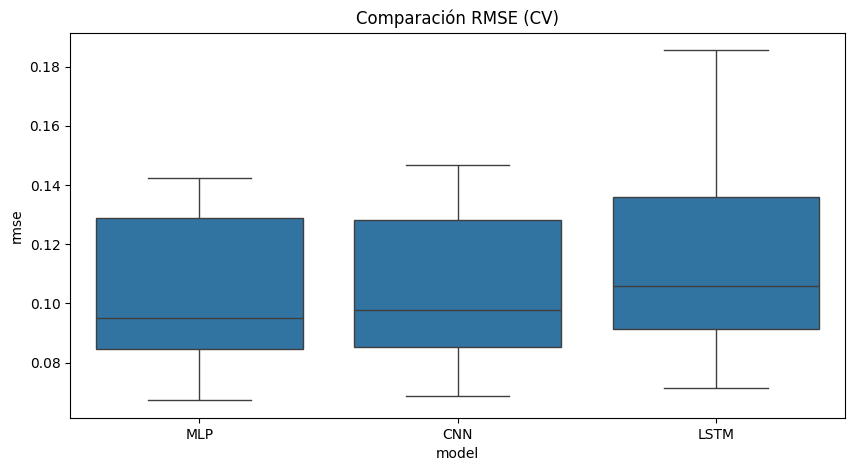

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=all_folds, x="model", y="rmse")
plt.title("Comparación RMSE (CV)")
plt.show()

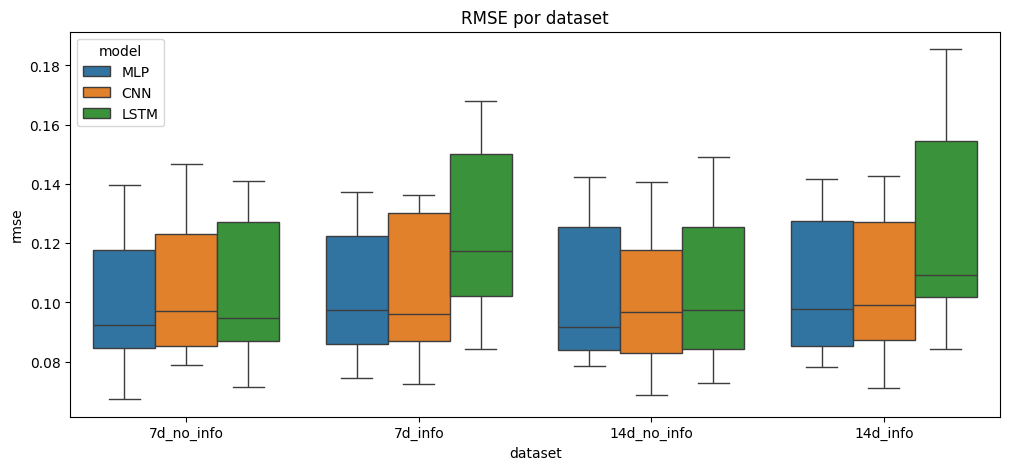

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=all_folds, x="dataset", y="rmse", hue="model")
plt.title("RMSE por dataset")
plt.show()

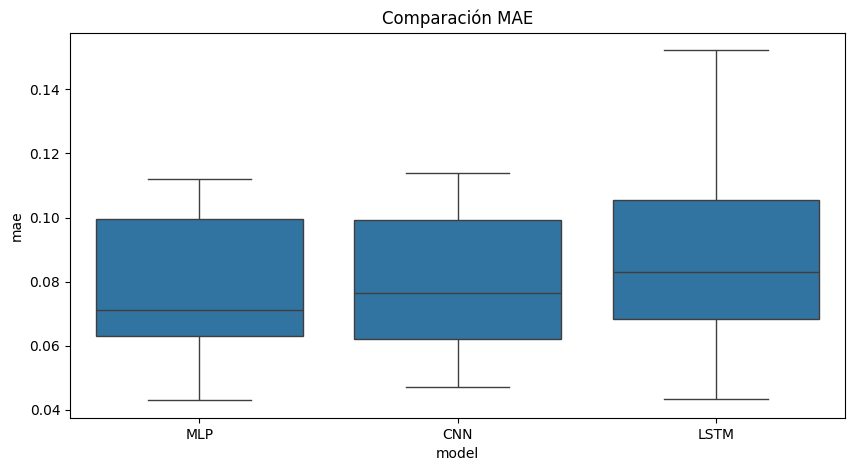

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=all_folds, x="model", y="mae")
plt.title("Comparación MAE")
plt.show()

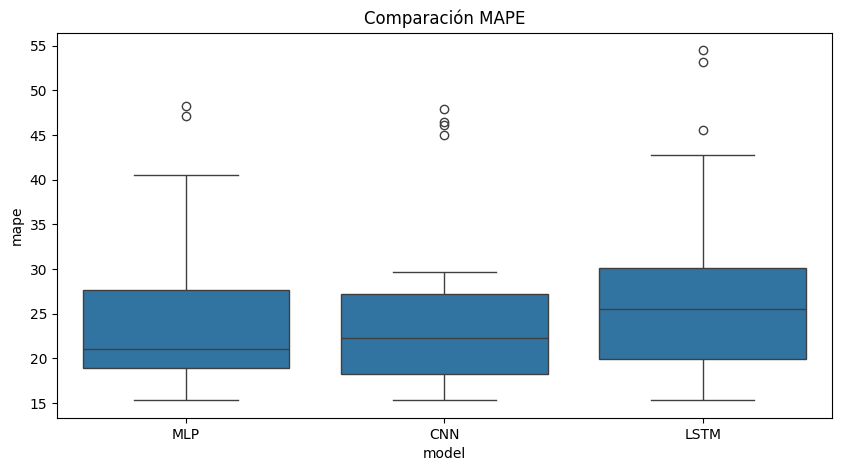

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=all_folds, x="model", y="mape")
plt.title("Comparación MAPE")
plt.show()

In [ ]:
rmse_matrix = all_folds.pivot(
    index="fold",
    columns="model_dataset",
    values="rmse"
)

# Eliminar filas incompletas
rmse_matrix = rmse_matrix.dropna()

rmse_matrix.shape

(10, 12)

In [ ]:
shapiro_df = pd.DataFrame(columns=["stat", "pvalue"])

for col in rmse_matrix.columns:
    data = rmse_matrix[col]

    if len(data) >= 3:
        stat, p = stats.shapiro(data)
    else:
        stat, p = np.nan, np.nan

    shapiro_df.loc[col] = [stat, p]

shapiro_df

,stat,pvalue
CNN_14d_info,0.919608,0.353694
CNN_14d_no_info,0.949466,0.662181
CNN_7d_info,0.861795,0.080116
CNN_7d_no_info,0.870786,0.102096
LSTM_14d_info,0.885793,0.151975
LSTM_14d_no_info,0.921005,0.365414
LSTM_7d_info,0.931790,0.465726
LSTM_7d_no_info,0.888638,0.163681
MLP_14d_info,0.850924,0.059578
MLP_14d_no_info,0.838908,0.042815


In [ ]:
friedman = stats.friedmanchisquare(
    *[rmse_matrix[col] for col in rmse_matrix.columns]
)

print(friedman)

FriedmanchisquareResult(statistic=np.float64(52.47692307692313), pvalue=np.float64(2.234229201163358e-07))


In [ ]:
if friedman.pvalue < 0.05:
    print("Existen diferencias significativas entre modelos")
else:
    print("No se detectan diferencias significativas")

Existen diferencias significativas entre modelos


In [ ]:
results_mlp["model"] = "MLP"
results_cnn["model"] = "CNN"
results_lstm["model"] = "LSTM"

results_all = pd.concat([results_mlp, results_cnn, results_lstm])

results_all

,dataset,cv_rmse,cv_mae,cv_mape,test_rmse,test_mae,test_mape,model
0,7d_no_info,0.099353,0.074213,22.613031,0.093781,0.067884,25.605426,MLP
1,7d_info,0.101914,0.079224,24.784234,0.099484,0.073199,27.610370,MLP
2,14d_no_info,0.104005,0.078810,24.105147,0.093132,0.065650,25.201608,MLP
3,14d_info,0.104872,0.081610,25.261501,0.093951,0.067786,26.021891,MLP
0,7d_no_info,0.104034,0.078597,24.458411,0.098710,0.073791,27.833755,CNN
1,7d_info,0.104467,0.079528,24.501457,0.097673,0.073851,27.856326,CNN
2,14d_no_info,0.101172,0.075672,23.282695,0.098427,0.072970,28.011667,CNN
3,14d_info,0.104235,0.080141,24.686581,0.104397,0.081668,31.350641,CNN
0,7d_no_info,0.102953,0.077113,23.607468,0.097208,0.073045,27.552194,LSTM
1,7d_info,0.123597,0.096925,29.997835,0.103522,0.075265,28.389430,LSTM


In [ ]:
baseline = pd.read_csv("results_baseline.csv")

results_all = pd.concat([results_all, baseline], ignore_index=True)

In [ ]:
results_all.sort_values("test_rmse")

,dataset,cv_rmse,cv_mae,cv_mape,test_rmse,test_mae,test_mape,model
2,14d_no_info,0.104005,0.078810,24.105147,0.093132,0.065650,25.201608,MLP
0,7d_no_info,0.099353,0.074213,22.613031,0.093781,0.067884,25.605426,MLP
3,14d_info,0.104872,0.081610,25.261501,0.093951,0.067786,26.021891,MLP
10,14d_no_info,0.104474,0.078311,24.099335,0.094992,0.068798,26.410415,LSTM
8,7d_no_info,0.102953,0.077113,23.607468,0.097208,0.073045,27.552194,LSTM
5,7d_info,0.104467,0.079528,24.501457,0.097673,0.073851,27.856326,CNN
6,14d_no_info,0.101172,0.075672,23.282695,0.098427,0.072970,28.011667,CNN
4,7d_no_info,0.104034,0.078597,24.458411,0.098710,0.073791,27.833755,CNN
1,7d_info,0.101914,0.079224,24.784234,0.099484,0.073199,27.610370,MLP
9,7d_info,0.123597,0.096925,29.997835,0.103522,0.075265,28.389430,LSTM


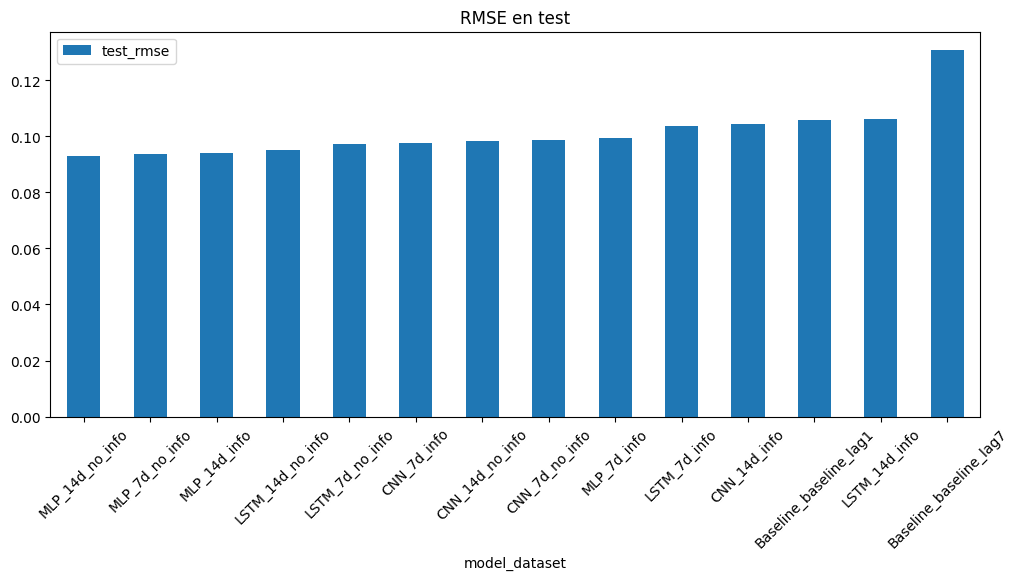

In [ ]:
results_all["model_dataset"] = results_all["model"] + "_" + results_all["dataset"]

results_all.sort_values("test_rmse").plot(
    x="model_dataset",
    y="test_rmse",
    kind="bar",
    figsize=(12,5)
)

plt.title("RMSE en test")
plt.xticks(rotation=45)
plt.show()

In [ ]:
results_all = results_all.set_index("model_dataset")

metrics = results_all[["test_rmse","test_mae","test_mape"]]

def normalize(df):
    return (df - df.min()) / (df.max() - df.min())

norm = normalize(metrics)

norm["TOTAL"] = norm.sum(axis=1)

ranking = norm.sort_values("TOTAL")

ranking

,test_rmse,test_mae,test_mape,TOTAL
model_dataset,,,,
MLP_14d_no_info,0.000000,0.000000,0.000000,0.000000
MLP_7d_no_info,0.017219,0.077952,0.040227,0.135399
MLP_14d_info,0.021731,0.074556,0.081715,0.178001
LSTM_14d_no_info,0.049319,0.109869,0.120418,0.279607
LSTM_7d_no_info,0.108097,0.258031,0.234160,0.600287
CNN_7d_info,0.120417,0.286163,0.264457,0.671037
MLP_7d_info,0.168461,0.263412,0.239955,0.671829
CNN_14d_no_info,0.140422,0.255407,0.279931,0.675760
CNN_7d_no_info,0.147933,0.284076,0.262208,0.694217


In [ ]:
ranking.sort_values("test_rmse")

,test_rmse,test_mae,test_mape,TOTAL
model_dataset,,,,
MLP_14d_no_info,0.000000,0.000000,0.000000,0.000000
MLP_7d_no_info,0.017219,0.077952,0.040227,0.135399
MLP_14d_info,0.021731,0.074556,0.081715,0.178001
LSTM_14d_no_info,0.049319,0.109869,0.120418,0.279607
LSTM_7d_no_info,0.108097,0.258031,0.234160,0.600287
CNN_7d_info,0.120417,0.286163,0.264457,0.671037
CNN_14d_no_info,0.140422,0.255407,0.279931,0.675760
CNN_7d_no_info,0.147933,0.284076,0.262208,0.694217
MLP_7d_info,0.168461,0.263412,0.239955,0.671829


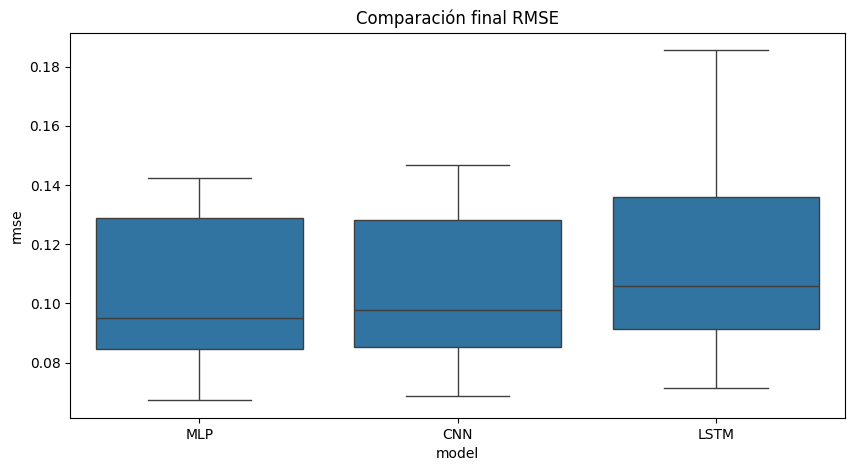

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=all_folds, x="model", y="rmse")
plt.title("Comparación final RMSE")
plt.show()

In [ ]:
print("Mejor modelo:")
print(ranking.index[0])

print("\nPeor modelo:")
print(ranking.index[-1])

Mejor modelo:
MLP_14d_no_info

Peor modelo:
Baseline_baseline_lag7
